# Демонстрация CUDA: CuPy и PyTorch

Ноутбук-практикум по технологии **CUDA**. Содержит:

1. Проверку окружения и доступности GPU.
2. Сравнение **NumPy (CPU)** и **CuPy (GPU)** на задачах линейной алгебры, поэлементных операциях и БПФ.
3. Сравнение **PyTorch CPU** и **PyTorch CUDA (cuDNN)** на операциях с тензорами и обучении нейросети.
4. Демонстрацию ускорения свёрток через cuDNN.

> Требование: видеокарта NVIDIA RTX, установленный CUDA Toolkit и cuDNN.

## 1. Проверка окружения

In [1]:
import subprocess, sys, platform
import torch
import numpy as np
import cupy as cp
import time, gc
import matplotlib.pyplot as plt
from torch import nn, optim
print('Python :', sys.version.split()[0])
print('OS     :', platform.platform())

try:
    out = subprocess.check_output(['nvidia-smi'], text=True)
    print(out)
except Exception as e:
    print('nvidia-smi недоступен:', e)

Python : 3.12.10
OS     : Windows-11-10.0.26100-SP0
Sat May 16 23:56:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P0             17W /   75W |    1125MiB /   8188MiB |      2%      Default |
|                                         |                        |                  N/

In [2]:
print('CuPy version       :', cp.__version__)
print('CUDA runtime (CuPy):', cp.cuda.runtime.runtimeGetVersion())
print('GPU device         :', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
print()
print('PyTorch version    :', torch.__version__)
print('CUDA available     :', torch.cuda.is_available())
print('CUDA device count  :', torch.cuda.device_count())
print('CUDA device name   :', torch.cuda.get_device_name(0))
print('cuDNN version      :', torch.backends.cudnn.version())
print('cuDNN enabled      :', torch.backends.cudnn.enabled)

CuPy version       : 14.0.1
CUDA runtime (CuPy): 12090
GPU device         : NVIDIA GeForce RTX 4060 Laptop GPU

PyTorch version    : 2.12.0+cu126
CUDA available     : True
CUDA device count  : 1
CUDA device name   : NVIDIA GeForce RTX 4060 Laptop GPU
cuDNN version      : 91002
cuDNN enabled      : True


## 2. NumPy (CPU) vs CuPy (GPU)

CuPy — это near drop-in замена NumPy, работающая через CUDA. API почти полностью совместим: достаточно заменить `import numpy as np` на `import cupy as cp`.

Ключевое отличие при замере времени GPU — нужно вызывать `cp.cuda.Stream.null.synchronize()`, иначе мы измерим только время постановки ядер в очередь, а не реального выполнения.

In [3]:
def bench_cpu(fn, repeat=3):
    fn()  # warmup
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn()
    return (time.perf_counter() - t0) / repeat

def bench_gpu(fn, repeat=3):
    fn(); cp.cuda.Stream.null.synchronize()  # warmup
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn()
    cp.cuda.Stream.null.synchronize()
    return (time.perf_counter() - t0) / repeat

In [4]:
# Матричное умножение C = A @ B
sizes = [1000, 2000, 4000, 8000]
matmul_results = []

for n in sizes:
    a_np = np.random.rand(n, n).astype(np.float32)
    b_np = np.random.rand(n, n).astype(np.float32)
    a_cp = cp.asarray(a_np)
    b_cp = cp.asarray(b_np)

    t_cpu = bench_cpu(lambda: a_np @ b_np, repeat=2)
    t_gpu = bench_gpu(lambda: a_cp @ b_cp, repeat=5)

    matmul_results.append((n, t_cpu, t_gpu))
    print(f'N={n:>5}  CPU: {t_cpu:8.3f} c   GPU: {t_gpu:8.4f} c   ускорение: x{t_cpu/t_gpu:7.1f}')
    del a_np, b_np, a_cp, b_cp; gc.collect(); cp.get_default_memory_pool().free_all_blocks()

N= 1000  CPU:    0.006 c   GPU:   0.0004 c   ускорение: x   15.8
N= 2000  CPU:    0.059 c   GPU:   0.0024 c   ускорение: x   24.3
N= 4000  CPU:    0.380 c   GPU:   0.0182 c   ускорение: x   20.9
N= 8000  CPU:    2.432 c   GPU:   0.1429 c   ускорение: x   17.0


In [5]:
# Поэлементные операции — exp(sin(x)^2 + cos(x)^2)
N = 50_000_000
x_np = np.random.rand(N).astype(np.float32)
x_cp = cp.asarray(x_np)

f_np = lambda: np.exp(np.sin(x_np)**2 + np.cos(x_np)**2)
f_cp = lambda: cp.exp(cp.sin(x_cp)**2 + cp.cos(x_cp)**2)

t_cpu = bench_cpu(f_np, repeat=3)
t_gpu = bench_gpu(f_cp, repeat=10)
print(f'Elementwise N={N:_}  CPU: {t_cpu:.3f} c   GPU: {t_gpu:.4f} c   x{t_cpu/t_gpu:.1f}')

Elementwise N=50_000_000  CPU: 0.396 c   GPU: 0.0138 c   x28.7


In [6]:
# Быстрое преобразование Фурье (FFT)
N = 2**24  # ~16.7 млн точек
x_np = np.random.rand(N).astype(np.complex64)
x_cp = cp.asarray(x_np)

t_cpu = bench_cpu(lambda: np.fft.fft(x_np), repeat=2)
t_gpu = bench_gpu(lambda: cp.fft.fft(x_cp), repeat=10)
print(f'FFT N=2^24  CPU: {t_cpu:.3f} c   GPU: {t_gpu:.4f} c   x{t_cpu/t_gpu:.1f}')

FFT N=2^24  CPU: 0.668 c   GPU: 0.0036 c   x188.0


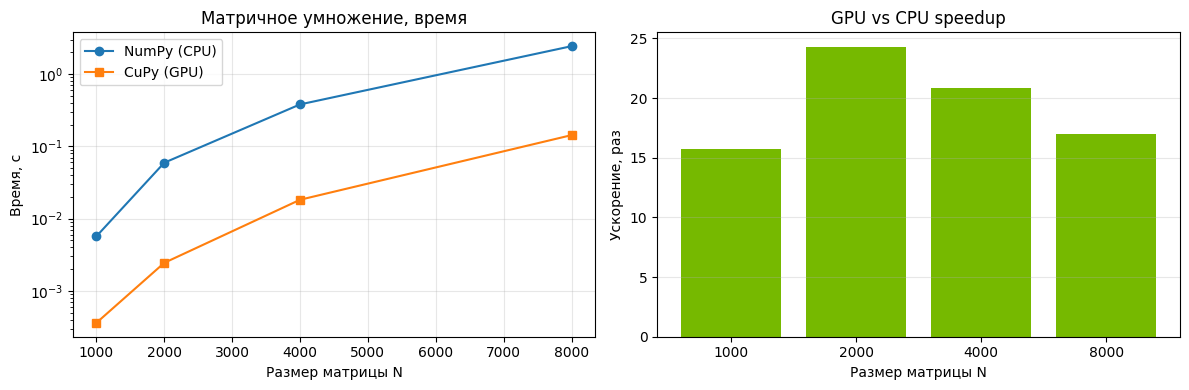

In [7]:
ns      = [r[0] for r in matmul_results]
cpu_t   = [r[1] for r in matmul_results]
gpu_t   = [r[2] for r in matmul_results]
speedup = [c/g for c, g in zip(cpu_t, gpu_t)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ns, cpu_t, 'o-', label='NumPy (CPU)')
ax[0].plot(ns, gpu_t, 's-', label='CuPy (GPU)')
ax[0].set_xlabel('Размер матрицы N'); ax[0].set_ylabel('Время, с')
ax[0].set_yscale('log'); ax[0].set_title('Матричное умножение, время'); ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].bar([str(n) for n in ns], speedup, color='#76b900')
ax[1].set_xlabel('Размер матрицы N'); ax[1].set_ylabel('Ускорение, раз')
ax[1].set_title('GPU vs CPU speedup'); ax[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('matmul_bench.png', dpi=120); plt.show()

## 3. PyTorch: CPU vs CUDA

PyTorch автоматически использует CUDA, если тензор переведён на устройство `cuda`. Под капотом для свёрток и BLAS-операций задействуются библиотеки **cuBLAS** и **cuDNN**, оптимизированные NVIDIA вручную.

In [8]:
device_cpu = torch.device('cpu')
device_gpu = torch.device('cuda')

def bench_torch(fn, device, repeat=5):
    fn()  # warmup
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeat

In [9]:
# Матричное умножение тензоров
torch_matmul = []
for n in [1000, 2000, 4000, 8000]:
    A_cpu = torch.randn(n, n, device=device_cpu)
    B_cpu = torch.randn(n, n, device=device_cpu)
    A_gpu = A_cpu.to(device_gpu)
    B_gpu = B_cpu.to(device_gpu)

    t_cpu = bench_torch(lambda: A_cpu @ B_cpu, device_cpu, repeat=2)
    t_gpu = bench_torch(lambda: A_gpu @ B_gpu, device_gpu, repeat=10)
    torch_matmul.append((n, t_cpu, t_gpu))
    print(f'N={n:>5}  CPU: {t_cpu:8.3f} c   GPU: {t_gpu:8.4f} c   x{t_cpu/t_gpu:7.1f}')
    del A_cpu, B_cpu, A_gpu, B_gpu
    torch.cuda.empty_cache()

N= 1000  CPU:    0.004 c   GPU:   0.0003 c   x   11.0
N= 2000  CPU:    0.030 c   GPU:   0.0025 c   x   11.9
N= 4000  CPU:    0.253 c   GPU:   0.0183 c   x   13.8
N= 8000  CPU:    1.439 c   GPU:   0.1457 c   x    9.9


In [10]:
# Свёрточный слой (cuDNN под капотом)
batch, ch_in, ch_out, H, W, k = 32, 64, 128, 224, 224, 3
conv_cpu = nn.Conv2d(ch_in, ch_out, k, padding=1).to(device_cpu)
conv_gpu = nn.Conv2d(ch_in, ch_out, k, padding=1).to(device_gpu)

x_cpu = torch.randn(batch, ch_in, H, W, device=device_cpu)
x_gpu = x_cpu.to(device_gpu)

t_cpu = bench_torch(lambda: conv_cpu(x_cpu), device_cpu, repeat=2)
t_gpu = bench_torch(lambda: conv_gpu(x_gpu), device_gpu, repeat=20)
print(f'Conv2D 32x64x224x224 ->128  CPU: {t_cpu:.3f} c   GPU: {t_gpu:.4f} c   x{t_cpu/t_gpu:.1f}')

Conv2D 32x64x224x224 ->128  CPU: 0.636 c   GPU: 0.0299 c   x21.2


In [11]:
# Полный цикл обучения небольшой свёрточной сети
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

def train_epoch(device, n_batches=50, batch=64):
    torch.manual_seed(0)
    model = TinyCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    x = torch.randn(batch, 3, 64, 64, device=device)
    y = torch.randint(0, 10, (batch,), device=device)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_batches):
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
    if device.type == 'cuda': torch.cuda.synchronize()
    return time.perf_counter() - t0

t_cpu = train_epoch(device_cpu)
t_gpu = train_epoch(device_gpu)
print(f'Training 50 batch  CPU: {t_cpu:.2f} c   GPU: {t_gpu:.3f} c   x{t_cpu/t_gpu:.1f}')

Training 50 batch  CPU: 3.24 c   GPU: 0.606 c   x5.3


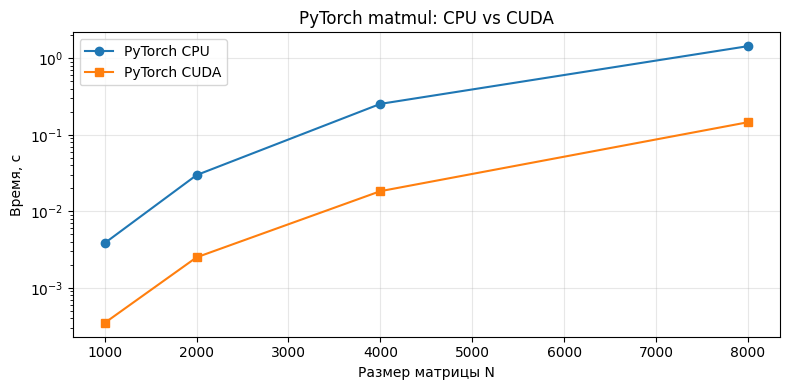

In [12]:
ns    = [r[0] for r in torch_matmul]
cpu_t = [r[1] for r in torch_matmul]
gpu_t = [r[2] for r in torch_matmul]

plt.figure(figsize=(8, 4))
plt.plot(ns, cpu_t, 'o-', label='PyTorch CPU')
plt.plot(ns, gpu_t, 's-', label='PyTorch CUDA')
plt.yscale('log')
plt.xlabel('Размер матрицы N'); plt.ylabel('Время, с')
plt.title('PyTorch matmul: CPU vs CUDA'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('torch_bench.png', dpi=120); plt.show()

## 4. Выводы

* На матричных операциях большого размера GPU обгоняет CPU в **десятки–сотни раз**.
* На малых задачах (N≤256) выгода от GPU нивелируется накладными расходами на запуск ядер и копирование памяти.
* PyTorch + cuDNN дают на свёртках кратное ускорение, что критично при обучении глубоких сетей.
* CuPy — самый дешёвый способ ускорить существующий NumPy-код: достаточно заменить импорт.